# Guardian AI: smart environmental surveillance 

This notebook guides you through building a **scene classification** system for environmental monitoring using the Places365 dataset. You'll start by selecting relevant environmental scene categories, filter and prepare the dataset, then follow the provided guide to **train a CNN from scratch**. Alternatively, you can implement a pre-trained architecture like ResNet50 on your own. The workflow includes comprehensive evaluation with confusion matrices and ends with a practical inference system.

### 1. Imports

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import transforms, datasets, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm  # for progress bar
import numpy as np
import random

import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint

import PIL.Image as Image

### 2. Data preparation

We use the **Places365 dataset**, which contains over **1.8 million images** across **365 environmental scene categories** including forests, deserts, urban areas, and agricultural zones.

Here we define the image preprocessing pipeline with **appropriate transforms** for training and validation data, including data augmentation techniques to make our model robust to real-world conditions.

- If you don't know how to implement transforms have a look here: https://docs.pytorch.org/vision/main/transforms.html
- Documentation to correctly load the Places365 dataset: https://pytorch.org/vision/stable/generated/torchvision.datasets.Places365.html

In [ ]:
# Step 1: Setting the path to the Places365 dataset
places_data_root = "/C/Usuarios/JoseBarros/Datasets/places365"  

# Step 2: Defining transforms for TRAINING data
# Data augmentation + standard preprocessing
# Guardian AI needs to be robust to different viewpoints and lighting
train_transforms = transforms.Compose([
    # Adding random crop and resize to 224x224
    transforms.RandomCrop(224),
    
    # Adding horizontal flip for data augmentation
    transforms.RandomHorizontalFlip(),
    
    # Converting to tensor
    transforms.ToTensor(),
    
    # Normalizing using ImageNet statistics
    # Mean: [0.485, 0.456, 0.406], Std: [0.229, 0.224, 0.225]
    transforms.Normalize(
        mean=[0.485,0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Step 3: Defining transforms for VALIDATION data
# No randomness - we want consistent evaluation results
val_transforms = transforms.Compose([
    # Resizing to 256 pixels (shorter edge)
    transforms.Resize(256),
    
    # Centering crop to 224x224
    transforms.CenterCrop(224),
    
    # Converting to tensor
    transforms.ToTensor(),
    
    # Same normalization as training
    transforms.Normalize(
        mean=[0.485,0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Step 4: Loading the Places365 datasets

full_train = datasets.Places365(
    root=places_data_root,                    # dataset path
    split="train-standard",                 # Using "train-standard" for training
    small=False,                   # False for high-resolution images
    transform=train_transforms,               #  Applying training transforms
    download=False
)

full_val = datasets.Places365(
    root=places_data_root,                    # dataset path  
    split="val",                 # "val" for validation
    small=False,                   # False for high-resolution images
    transform=val_transforms,               # Apply validation transforms
    download=False
)

# Verify your implementation
print(f"Training samples: {len(full_train)}")
print(f"Validation samples: {len(full_val)}")
print(f"Number of scene classes: {len(full_train.classes)}")

# Expected output:
# Training samples: ~1,800,000
# Validation samples: ~36,500  
# Number of scene classes: 365

Training samples: 1803460
Validation samples: 36500
Number of scene classes: 365


### 3. Categories selection

For our Guardian AI monitoring system, we don't need all 365 scene categories - instead, we focus on the most relevant environmental contexts where protected area monitoring typically occurs. In this step, we **select approximately 15-18 scene categories** that represent the diverse ecosystems and terrains our drones and camera traps will encounter.

In [21]:
# Step 1: Examine available categories
categories = full_train.classes
print("First 20 categories from Places365:")
print(categories[:20])
print(f"\nTotal available categories: {len(categories)}")

First 20 categories from Places365:
['/a/airfield', '/a/airplane_cabin', '/a/airport_terminal', '/a/alcove', '/a/alley', '/a/amphitheater', '/a/amusement_arcade', '/a/amusement_park', '/a/apartment_building/outdoor', '/a/aquarium', '/a/aqueduct', '/a/arcade', '/a/arch', '/a/archaelogical_excavation', '/a/archive', '/a/arena/hockey', '/a/arena/performance', '/a/arena/rodeo', '/a/army_base', '/a/art_gallery']

Total available categories: 365


In [ ]:
#Printing categories that contain the word 'ocean'
ocean_categories = [cat for cat in categories if 'ocean' in cat]
print(ocean_categories)

['/o/ocean', '/u/underwater/ocean_deep']


In [ ]:
# Printing categories that contain the word 'savanna'
savanna_categories = [cat for cat in categories if 'savanna' in cat]
print(savanna_categories)

[]


In [ ]:
# Printing categories that contain the word 'water'
water_categories = [cat for cat in categories if 'water' in cat]
print(water_categories)

['/m/moat/water', '/u/underwater/ocean_deep', '/w/water_park', '/w/water_tower', '/w/waterfall', '/w/watering_hole']


In [ ]:
# Step 2: Selecting 15-18 environmental categories relevant for protected area monitoring
# Let's think about different ecosystems where environmental monitoring is crucial
#For the scope of this project, as mentioned in the README, we focused on water ecosystems 

selected_categories = [
    '/b/bamboo_forest',
    '/c/coast',
    '/d/desert/sand',
    '/d/desert/vegetation',
    '/g/glacier',
    '/i/iceberg',
    '/l/lake/natural',
    '/m/mountain',
    '/m/mountain_snowy',
    '/o/ocean',
    '/p/pond',
    '/r/rainforest',
    '/r/river',
    '/t/tundra',
    '/u/underwater/ocean_deep'
]

# Step 3: Defining the number of classes selected and verifying all categories exist in the dataset
num_classes = len(selected_categories)


In [ ]:
print(num_classes) #Must be the same as the length of selected_categories

15


In [ ]:
# Step 4: Verifying all categories exist in the dataset
selected_category_indices = [i for i, cat in enumerate(categories) if cat in selected_categories]
print(f"Found {len(selected_category_indices)} valid categories in dataset")

Found 15 valid categories in dataset


In [ ]:
#Checking the cateries's indices inside the Places365 dataset
for i in selected_category_indices:
    print(f"{i}: {categories[i]}")


36: /b/bamboo_forest
97: /c/coast
116: /d/desert/sand
117: /d/desert/vegetation
163: /g/glacier
190: /i/iceberg
205: /l/lake/natural
232: /m/mountain
234: /m/mountain_snowy
243: /o/ocean
271: /p/pond
279: /r/rainforest
288: /r/river
341: /t/tundra
342: /u/underwater/ocean_deep


In [ ]:
## Configuration for the Places365 dataset
CPU_COUNT = os.cpu_count()

In [ ]:
# This line uses os.cpu_count() to detect how many CPU cores are available in the current environment.
# On HPC systems like Leonardo (CINECA), this does NOT return the total number of cores on the machine,
# but rather the number of logical CPU cores that have been allocated to the current job by the scheduler (e.g., SLURM).
# If this returns 32, it means the job was allocated 32 CPU cores—not that the program is using all of them.
# To take full advantage of them, we will need to implement parallel processing (e.g., multiprocessing, joblib).
CPU_COUNT = os.cpu_count()
CPU_COUNT

32

### 4. Filtering dataset indices for selected categories

Now that we've chosen our environmental categories, we need to identify which images in the massive Places365 dataset belong to our selected categories. With over 1.8 million training images, checking each one sequentially would take hours. Instead, we'll use parallel processing with ThreadPoolExecutor to speed up this filtering process. We create a function that checks if each image belongs to one of our selected categories, then run it across multiple CPU cores simultaneously. The result is a list of indices pointing to only the images we need for training our Guardian AI system, which we'll save to disk to avoid repeating this time-intensive process.



In [ ]:
def is_selected_train(i):
    """
    Function to check if training image at index i belongs to our selected categories.
    
    Args:
        i (int): Index of the image in full_train dataset
        
    Returns:
        int or None: Returns i if image belongs to selected categories, None otherwise
    """
    try:
        # Getting the image and label from full_train at index i
        
        image, label = full_train[i]
        
        # Checking if this label is in our selected_category_indices
        # Return i if yes, None if no
        if label in selected_category_indices:
            return i
        else: 
            return None
        
        
    except Exception:
        # Handling corrupted images or other errors
        return None


In [ ]:
# Using ThreadPoolExecutor to process training set in parallel
with ThreadPoolExecutor(max_workers=CPU_COUNT) as executor:
    
    # Mapping is_selected_train function across all training indices, obtaining the range of indices to test
    # Using tqdm for progress bar
    selected_indices_train = list(tqdm(
        executor.map(is_selected_train, range(len(full_train))), 
        total=len(full_train),
        desc="Training"
    ))

# Removing None values from the results
# We Use list comprehension to keep only non-None values
selected_indices_train = [i for i in selected_indices_train if i is not None]

print(f"Found {len(selected_indices_train):,} training images from selected categories")

Training:   6%|▌         | 101238/1803460 [01:13<22:58, 1234.53it/s] 

In [ ]:
def is_selected_val(i):
    """
    Function to check if validation image at index i belongs to our selected categories.
    Args:
        i (int): Index of the image in full_val dataset
        
    Returns:
        int or None: Returns i if image belongs to selected categories, None otherwise
    """
    try:
        # Similar to above but use full_val dataset
        image , label = full_val[i]
        
        if label in selected_category_indices:
            return i
        else: None
        
    except Exception:
        return None


In [ ]:
with ThreadPoolExecutor(max_workers=CPU_COUNT) as executor:  # Use fewer workers for smaller dataset
    selected_indices_val = list(tqdm(
        executor.map(is_selected_val, range(len(full_val))), 
        total=len(full_val),
        desc="Validation"
    ))

# Filtering out None values
selected_indices_val = [i for i in selected_indices_val if i is not None]

print(f"Found {len(selected_indices_val):,} validation images from selected categories")

In [ ]:
# Saving the indices to avoid recomputing this expensive operation
np.save("/C/Usuarios/JoseBarros/Datasets/selected_indices_train.npy", selected_indices_train)



In [ ]:
np.save("/C/Usuarios/JoseBarros/Datasets/selected_indices_val.npy", selected_indices_val)   
|

In [ ]:
# For future notebook runs, you can load saved indices instead:
selected_indices_train = np.load("/C/Usuarios/JoseBarros/Datasets/selected_indices_train.npy").tolist()
selected_indices_val = np.load("/C/Usuarios/JoseBarros/Datasets/selected_indices_val.npy").tolist()

## selected_indices_train

If the training set is too large and you want to reduce its size in order to test the entire code before the final training run, you can randomly select half of the indices or a portion of them.

In [5]:
reduced_size = len(selected_indices_train)//3
reduced_indices = random.sample(selected_indices_train, reduced_size)

### 5. Filter dataset and label remapping

After identifying relevant image indices, we need to create filtered datasets containing only our selected environmental categories. However, there's a crucial issue: the original Places365 labels range from 0-364, but our 18 selected categories will have scattered indices (e.g., 45, 123, 200, etc.). Machine learning models expect consecutive labels starting from 0, so we must remap our categories from their original scattered indices to a clean 0-17 range. We also create a custom Dataset class that handles this remapping automatically. 

In [ ]:
# Step 1: filter the dataset
# We create subsets using the filtered indices
filtered_subset_train = Subset(full_train, reduced_indices)  # Using full_train with the selected indices (or reduced_indices)
filtered_subset_val = Subset(full_val, selected_indices_val)    # Using full_val with selected_indices_val

In [11]:
{cat: i for i, cat in enumerate(selected_categories)}

{'/b/bamboo_forest': 0,
 '/c/coast': 1,
 '/d/desert/sand': 2,
 '/d/desert/vegetation': 3,
 '/g/glacier': 4,
 '/i/iceberg': 5,
 '/l/lake/natural': 6,
 '/m/mountain': 7,
 '/m/mountain_snowy': 8,
 '/o/ocean': 9,
 '/p/pond': 10,
 '/r/rainforest': 11,
 '/r/river': 12,
 '/t/tundra': 13,
 '/u/underwater/ocean_deep': 14}

In [ ]:
# Step2: implement custom Dataset class for label remapping
class RemappedSubset(Dataset):
    """
    Why do we need remapping?
    - Original Places365 has labels like [5, 23, 156, 299] for our selected categories
    - ML models need consecutive labels [0, 1, 2, 3] for proper training
    - This class automatically converts scattered labels to consecutive ones
    """
    
    def __init__(self, subset, selected_categories):
        # Storing the indices and original dataset
        self.indices = subset.indices.copy()  # Copies the list of indices
        self.orig_dataset = subset.dataset               # Stores reference to original dataset
        
        # Creating a mapping dictionary from category path to new index
        # Structure: {category: index for index, category in enumerate(selected_categories)}
        self.cat2idx = {cat: i for i, cat in enumerate(selected_categories)}
        self.categories = selected_categories
        
        print(f"Created remapping for {len(selected_categories)} categories")
    
    def __len__(self):
        # Returning the length of indices
        return len(self.indices)
    
    def __getitem__(self, idx):        
        # Gets the original index and retrieves image + label
        original_index = self.indices[idx]              # Get true index
        img, label = self.orig_dataset[original_index]             # Gets image and original label
        
        # Converts original label to category path, then to new label
        class_path = self.orig_dataset.classes[label]     # Gets category string
        new_label = self.cat2idx[class_path]                   # Maps to new consecutive label
        
        return img, new_label

In [ ]:
classes = filtered_subset_train.dataset.classes
labels_present = set()

for idx in filtered_subset_train.indices:
    _, label = filtered_subset_train.dataset[idx]
    labels_present.add(label)

print("Categories in filtered_subset_train:")
for label in sorted(labels_present):
    print(classes[label])  #checking the categories selected


KeyboardInterrupt: 

In [8]:
# Step 3:: Create the remapped datasets
train_dataset = RemappedSubset(filtered_subset_train, selected_categories)  # Use the filtered dataset for training and the list of the selected categories
val_dataset = RemappedSubset(filtered_subset_val, selected_categories)    # Use the filtered dataset for validation and the list of the selected categories

Created remapping for 15 categories
Created remapping for 15 categories


In [ ]:
#checking the shape of the first image in the dataset
np.array(train_dataset[0][0]).shape

/tmp/ipykernel_1210528/3711636227.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(train_dataset[0][0]).shape


(3, 224, 224)

In [ ]:
# Verify that label remapping works correctly
unique_labels = set()
sample_size = min(500, len(train_dataset))

# Sample some images and collect their new labels
for i in random.sample(range(len(train_dataset)), k=sample_size):
    img, label = train_dataset[i]  # Get label from train_dataset
    unique_labels.add(label)

print(f"Found labels: {sorted(unique_labels)}")
print(f"Expected: {list(range(len(selected_categories)))}")

#Must print a sequence from 0 to the total number of selected categories
#If it skips a number, for example: [0,1,2,4,5...] means that there's a problem with the selected_categories and must be corrected


Found labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Expected: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


### 6. Model definition

In the following part we define our vision model using PyTorch Lightning. The SimpleCNNLightning class implements a convolutional neural network with:

- Three convolutional layers (32, 64, 128 filters) with ReLU activation and max pooling for feature extraction
- Two fully connected layers with dropout for classification
- Built-in training/validation logic with automatic loss and accuracy logging
- Adam optimizer configuration for efficient training

The model takes 224x224 RGB images and outputs class probabilities for environment classification (forest, urban, desert, agricultural zones).


In [ ]:
torch.set_float32_matmul_precision('high') #We want the precision of our matrices calculations to be high

In [ ]:
class SimpleCNNLightning(pl.LightningModule):
    def __init__(self, num_classes, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        
        # Define the convolutional layers
        # conv1: 3 input channels -> 32 output channels, 3x3 kernel, padding=1
        self.conv1 = nn.Conv2d(3,32, kernel_size = 3 ,padding = 1)
        
        # conv2: 32 input channels -> 64 output channels, 3x3 kernel, padding=1
        self.conv2 = nn.Conv2d(32,64,kernel_size = 3, padding = 1)
        
        # conv3: 64 input channels -> 128 output channels, 3x3 kernel, padding=1
        self.conv3 = nn.Conv2d(64,128,kernel_size = 3, padding = 1)
        
        # Define pooling layer (2x2 max pooling)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Define fully connected layers
        # fc1: flattened features (128 * 28 s* 28) -> 256 neurons
        self.fc1 = nn.Linear(128*28*28, 256) #nn.Flatten(128*28*28, 256)
        
        # fc2: 256 neurons -> num_classes (final classification layer)
        self.fc2 = nn.Linear(256, num_classes)
        
        # Define dropout layer (0.5 dropout rate)
        self.dropout = nn.Dropout(0.5)
        
        # Define loss function (CrossEntropyLoss)
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, x):
        # Implement the forward pass
        # Apply conv1 -> ReLU -> pooling (224x224 -> 112x112)
        
        x= self.pool(F.relu(self.conv1(x)))
        
        # Apply conv2 -> ReLU -> pooling (112x112 -> 56x56)
        x = self.pool(F.relu(self.conv2(x)))
        
        # Apply conv3 -> ReLU -> pooling (56x56 -> 28x28)
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten the tensor for fully connected layers
        x = x.view(x.size(0), -1)
        
        # Apply fc1 -> ReLU -> dropout
        x = self.dropout(F.relu(self.fc1(x)))
        
        #  Apply final classification layer (fc2)
        x = self.fc2(x)
        
        return x
    
    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        
        # Get model predictions
        outputs = self(inputs)
        
        # Calculate loss
        loss = self.criterion(outputs, labels)
        
        # Calculate accuracy
        acc = (outputs.argmax(dim=1) == labels).float().mean()
        
        # Log metrics
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        
        # Get model predictions
        outputs = self(inputs)
        # Calculate loss
        loss = self.criterion(outputs, labels)
        
        # Calculate accuracy
        acc = (outputs.argmax(dim=1) == labels).float().mean()
        
        # Log metrics
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
    
    def configure_optimizers(self):
        # Return Adam optimizer with learning rate from hyperparameters
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

### 7. Training loop

Now, we are ready to set up and execute the training process for our model using PyTorch Lightning's Trainer. Key components include:

- **DataLoaders**: batch loading for training (shuffled) and validation (sequential) data
- **ModelCheckpoint**: automatically saves the best model based on validation accuracy
- **Trainer configuration**: handles multi-GPU training, epoch management, and distributed training
- **Training execution**: fits the model using the configured trainer with train/validation data

The trainer uses up to 4 GPUs with Distributed Data Parallel (DDP) strategy for faster training on larger datasets.

In [ ]:

#  Create training DataLoader
# Use batch_size=32, shuffle=True, num_workers=8
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers = 8)

# Create validation DataLoader  
# Use batch_size=32, shuffle=False, num_workers=8
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers = 8)


# Checkpoint callback (saves best model based on validation accuracy)
checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="best-checkpoint-"
)

# Initialize the model
# Pass the number of classes from selected_categories
model = SimpleCNNLightning(len(selected_categories))

# Create the PyTorch Lightning Trainer
trainer = pl.Trainer(accelerator="gpu", devices=2, strategy="ddp_notebook",
                     max_epochs=10, callbacks=[checkpoint_callback])

# Configure with:
# - max_epochs=10
# - accelerator="gpu" 
# - devices=2
# - strategy="ddp_notebook"
# - callbacks=[checkpoint_callback]


t0 = time.time()
# Start training
trainer.fit(model, train_loader, val_loader)

t1 = time.time()'''

/leonardo_scratch/fast/tra25_bbs/venv_proj_cv/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /leonardo_scratch/fast/tra25_bbs/venv_proj_cv/lib/py ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/leonardo_scratch/fast/tra25_bbs/venv_proj_cv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to 

RuntimeError: Lightning can't create new processes if CUDA is already initialized. Did you manually call `torch.cuda.*` functions, have moved the model to the device, or allocated memory on the GPU any other way? Please remove any such calls, or change the selected strategy. You will have to restart the Python kernel.

In [20]:
train_loader.dataset[1]

(tensor([[[ 2.0605,  2.0605,  2.0605,  ..., -0.7308, -0.4739, -0.9877],
          [ 2.0605,  2.0605,  2.0605,  ..., -0.9534, -1.1247, -0.9534],
          [ 2.0605,  2.0605,  2.0605,  ..., -1.0733, -0.6965, -0.6623],
          ...,
          [ 1.0331,  0.9988,  0.9817,  ..., -0.1657, -0.1486, -0.0801],
          [ 1.0331,  0.9988,  0.9817,  ...,  0.0227,  0.0398,  0.0741],
          [ 0.9646,  0.9474,  0.9303,  ...,  0.0056,  0.0398,  0.0741]],
 
         [[ 1.9034,  1.9034,  1.9034,  ..., -0.3025,  0.0126, -0.4951],
          [ 1.9034,  1.9034,  1.9034,  ..., -0.5301, -0.6527, -0.4951],
          [ 1.9034,  1.9034,  1.9034,  ..., -0.6527, -0.2675, -0.2850],
          ...,
          [ 1.9909,  1.9559,  1.9384,  ...,  1.4482,  1.4657,  1.4832],
          [ 1.9559,  1.9209,  1.9209,  ...,  1.6408,  1.6583,  1.6933],
          [ 1.8859,  1.8683,  1.8683,  ...,  1.6232,  1.6583,  1.6933]],
 
         [[ 1.8731,  1.8731,  1.8731,  ..., -1.4036, -1.1073, -1.5779],
          [ 1.8731,  1.8731,

In [15]:
model = SimpleCNNLightning(num_classes=len(selected_categories))

In [ ]:
#This line is used to load a pre-trained model checkpoint if it's saved as a dictionary.
# model.load_state_dict(torch.load("/C/Usuarios/JoseBarros/Datasets/lightning_logs/version_13/checkpoints/best-checkpoint-.ckpt"))

/tmp/ipykernel_1210528/2995017352.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/leonardo_work/tra25_bbs/jbarrosl/team_project/cv/lig

RuntimeError: Error(s) in loading state_dict for SimpleCNNLightning:
	Missing key(s) in state_dict: "conv1.weight", "conv1.bias", "conv2.weight", "conv2.bias", "conv3.weight", "conv3.bias", "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias". 
	Unexpected key(s) in state_dict: "epoch", "global_step", "pytorch-lightning_version", "state_dict", "loops", "callbacks", "optimizer_states", "lr_schedulers", "hparams_name", "hyper_parameters". 

In [23]:
print('Training time: ',t1-t0,'s')

Training time:  109.48723769187927 s


### 8. Evaluation and confusion matrix

Once we've trained our model, we can evaluate it and visualize its performance through a confusion matrix. The process includes:

- **Model loading**: load the best saved checkpoint (if available) or use the recently trained model
- **Device setup**: move model to GPU/CPU for inference
- **Prediction collection**: run inference on validation data without gradient computation
- **Accuracy calculation**: compute overall validation accuracy across all environment classes
- **Confusion matrix**: visualize classification performance showing correct/incorrect predictions per class

The confusion matrix helps identify which environment types the model confuses most often, crucial for improving Guardian AI's reliability in the field.

Using device: cuda
Overall Validation Accuracy: 0.4233


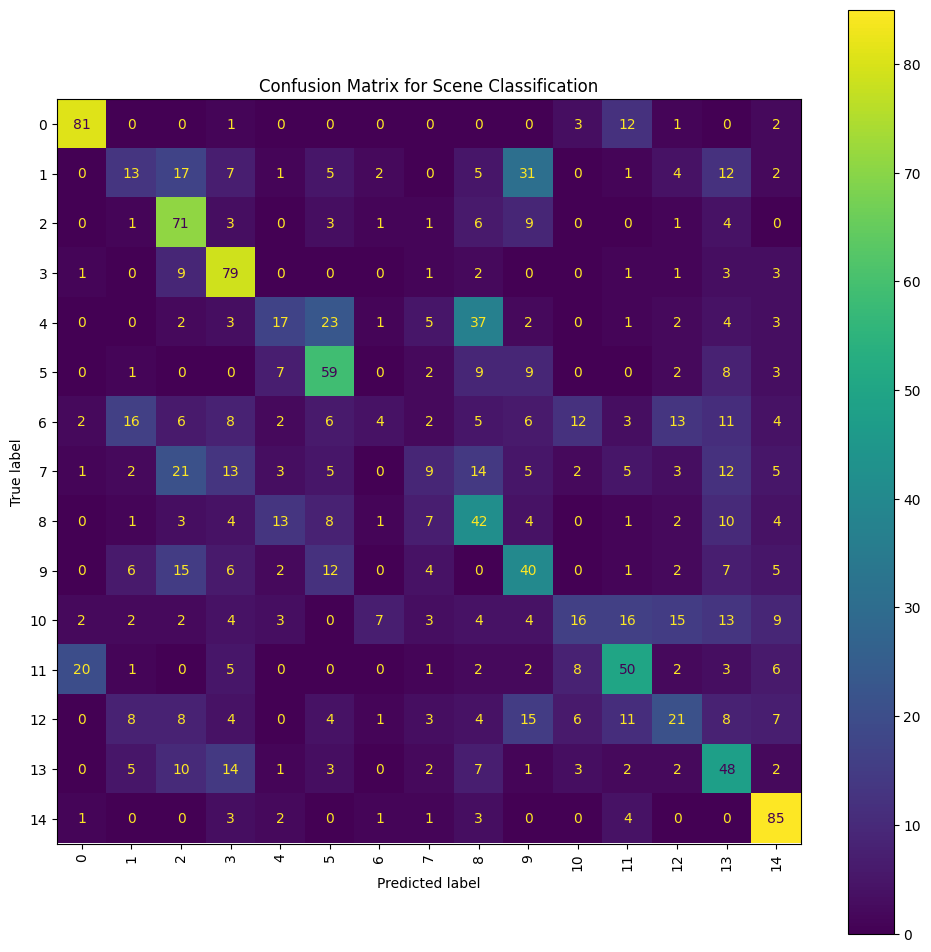

In [ ]:
# Model loading (choose one approach):
#this is the proper way, in this case, to load the model
# OPTION 1: If you have a saved checkpoint, uncomment and modify the path:
model = SimpleCNNLightning.load_from_checkpoint(torch.load("/C/Usuarios/JoseBarros/Datasets/lightning_logs/version_13/checkpoints/best-checkpoint-.ckpt", num_classes=num_classes)) # You should find a folder called 'lightening_logs' inside your own folder

# OPTION 2: If you just trained the model above, you can use it directly
# (model is already available from the previous training cell)

# Set up device for evaluation: Uses GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
#model.to_device()
model.eval()
# Move model to device and set to evaluation mode
#model = SimpleCNNLightning(len(classes)).to(device)

# Gather predictions & labels
all_preds = []
all_labels = []

# Disable gradient computation for evaluation
with torch.no_grad():
    for inputs, labels in val_loader:
        # Move inputs and labels to device
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Get model predictions
        outputs = model(inputs)
        
        # Get predicted classes (use torch.max to find the class with highest probability)
        _, preds = torch.max(outputs,1)
        
        # Store predictions and labels (convert to CPU numpy arrays)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#  Convert lists to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

#  Compute overall accuracy
overall_acc = (all_preds == all_labels).mean()
print(f"Overall Validation Accuracy: {overall_acc:.4f}")

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

#  Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

#  Create and show the plot
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation="vertical")
plt.title("Confusion Matrix for Scene Classification")
plt.show()

### 9. Sample inference 

Here we can check how Guardian AI performs real-world scene classification on individual images. 

Testing on 5 random images from our selected validation categories...
Selected indices: [33781, 15709, 13783, 22698, 13421]


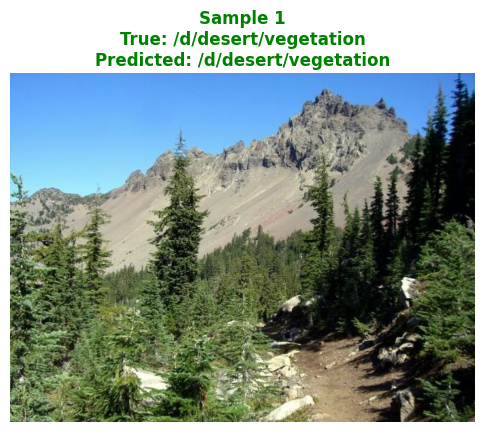

Image: Places365_val_00033782.jpg
True Label: /d/desert/vegetation
Predicted: /d/desert/vegetation - ✓ CORRECT
--------------------------------------------------


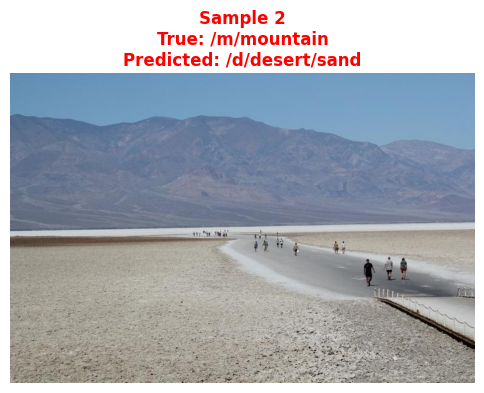

Image: Places365_val_00015710.jpg
True Label: /m/mountain
Predicted: /d/desert/sand - ✗ INCORRECT
--------------------------------------------------


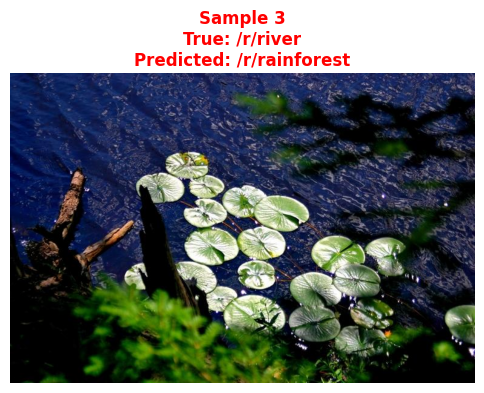

Image: Places365_val_00013784.jpg
True Label: /r/river
Predicted: /r/rainforest - ✗ INCORRECT
--------------------------------------------------


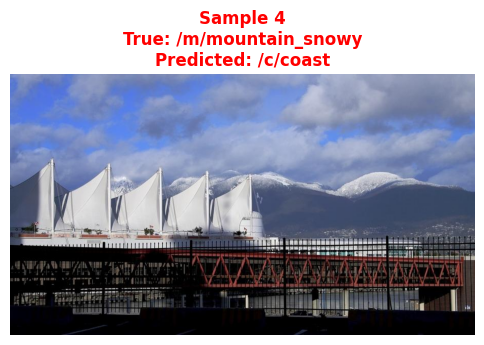

Image: Places365_val_00022699.jpg
True Label: /m/mountain_snowy
Predicted: /c/coast - ✗ INCORRECT
--------------------------------------------------


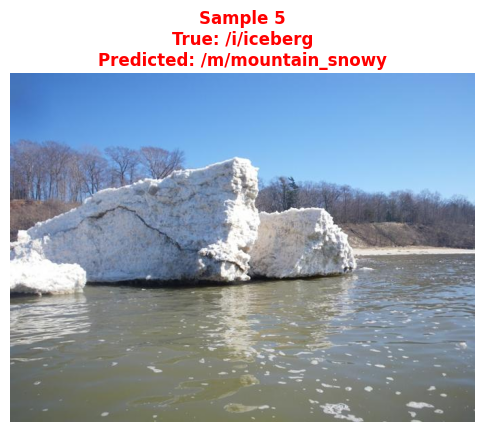

Image: Places365_val_00013422.jpg
True Label: /i/iceberg
Predicted: /m/mountain_snowy - ✗ INCORRECT
--------------------------------------------------

Sample Accuracy: 1/5 = 20.00%


In [22]:
def predict_scene(image_path, model, transform, class_names):
    img = Image.open(image_path).convert("RGB")
    inp = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out = model(inp)
        _, pred = torch.max(out, 1)
    return class_names[pred.item()]

# Randomly select 5 images from our filtered validation indices
import random
sample_indices = random.sample(selected_indices_val, 5)
test_images = []
true_labels = []

for idx in sample_indices:
    # Get the image path and true label from the original validation dataset
    img_path, true_class_idx = full_val.imgs[idx]
    test_images.append(img_path)
    true_labels.append(categories[true_class_idx])

print(f"Testing on 5 random images from our selected validation categories...")
print(f"Selected indices: {sample_indices}")

correct_predictions = 0
for i, (img_path, true_label) in enumerate(zip(test_images, true_labels)):
    try:
        predicted_label = predict_scene(img_path, model, val_transforms, selected_categories)
        img = Image.open(img_path).convert("RGB")
        
        # Check if prediction is correct
        is_correct = predicted_label == true_label
        if is_correct:
            correct_predictions += 1
            
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        title_color = 'green' if is_correct else 'red'
        plt.title(f"Sample {i+1}\nTrue: {true_label}\nPredicted: {predicted_label}", 
                 fontsize=12, fontweight='bold', color=title_color)
        plt.axis("off")
        plt.show()
        
        status = "✓ CORRECT" if is_correct else "✗ INCORRECT"
        print(f"Image: {img_path.split('/')[-1]}")
        print(f"True Label: {true_label}")
        print(f"Predicted: {predicted_label} - {status}")
        print("-" * 50)
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")

print(f"\nSample Accuracy: {correct_predictions}/{len(test_images)} = {correct_predictions/len(test_images):.2%}")